# PyTorch CNNs — From Manual Convolution to ResNet

Builds from a hand-rolled 2D convolution through `nn.Conv2d`, LeNet, residual blocks, and training on CIFAR-10.

In [ ]:
%pip install torchvision

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
## 1. 2D Convolution — From Scratch

A convolution slides a small kernel over the image, computing a dot product at each position.

$$y[h, w] = \sum_{i=0}^{k-1}\sum_{j=0}^{k-1} x[h+i,\, w+j] \cdot K[i, j]$$

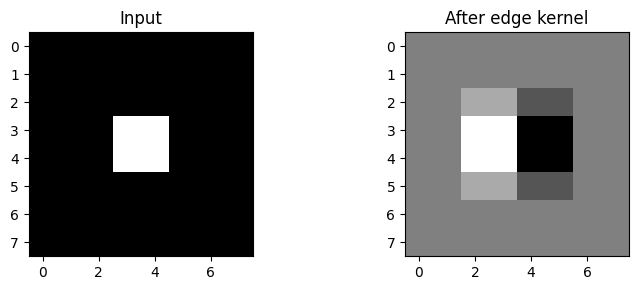

In [2]:
def conv2d_manual(x, kernel, stride=1, padding=0):
    """
    x:      (H, W)  — single-channel 2D input
    kernel: (k, k)  — convolution kernel
    Returns output of shape ((H-k+2p)//s+1, (W-k+2p)//s+1)
    """
    if padding > 0:
        x = F.pad(x.unsqueeze(0).unsqueeze(0), [padding] * 4).squeeze()
    H, W = x.shape
    k = kernel.shape[0]
    out_H = (H - k) // stride + 1
    out_W = (W - k) // stride + 1
    output = torch.zeros(out_H, out_W)
    for h in range(out_H):
        for w in range(out_W):
            patch = x[h * stride : h * stride + k, w * stride : w * stride + k]
            output[h, w] = (patch * kernel).sum()
    return output


# Test on a simple image
image = torch.zeros(8, 8)
image[3:5, 3:5] = 1.0  # small bright square

# Edge-detection kernel (Sobel-like)
kernel_edge = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]])

out = conv2d_manual(image, kernel_edge, padding=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Input")
axes[1].imshow(out, cmap="gray")
axes[1].set_title("After edge kernel")
plt.tight_layout()
plt.show()

In [3]:
# Verify our manual conv matches PyTorch's F.conv2d
x4d = image.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
k4d = kernel_edge.unsqueeze(0).unsqueeze(0)  # (1, 1, k, k)
pt_out = F.conv2d(x4d, k4d, padding=1).squeeze()
print(f"Max absolute difference: {(out - pt_out).abs().max().item():.2e}")

Max absolute difference: 0.00e+00


---
## 2. `nn.Conv2d` — Key Parameters

In [4]:
# nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)

print(f"Weight shape: {conv.weight.shape}")  # (out_ch, in_ch, k, k)
print(f"Bias shape:   {conv.bias.shape}")  # (out_ch,)

# Spatial formula:
# out_size = floor((in_size + 2*padding - kernel_size) / stride) + 1
# With padding=1, kernel=3, stride=1: output same size as input
img = torch.randn(4, 3, 32, 32)  # batch=4, RGB, 32x32
out = conv(img)
print(f"Input:  {img.shape}")
print(f"Output: {out.shape}")  # (4, 16, 32, 32) — same spatial, more channels

# Show receptive field growth with depth
print("\nReceptive field after L conv layers (3x3, stride=1):")
for L in [1, 2, 4, 8, 16]:
    rf = L * (3 - 1) + 1
    print(f"  L={L:2d}  RF={rf}")

Weight shape: torch.Size([16, 3, 3, 3])
Bias shape:   torch.Size([16])
Input:  torch.Size([4, 3, 32, 32])
Output: torch.Size([4, 16, 32, 32])

Receptive field after L conv layers (3x3, stride=1):
  L= 1  RF=3
  L= 2  RF=5
  L= 4  RF=9
  L= 8  RF=17
  L=16  RF=33


---
## 3. Pooling Layers

In [5]:
x = torch.randn(2, 8, 16, 16)  # batch=2, 8 channels, 16x16

# Max pooling: takes strongest activation in each 2x2 window
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
print(f"MaxPool2d:     {x.shape} -> {max_pool(x).shape}")  # (2, 8, 8, 8)

# Average pooling
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
print(f"AvgPool2d:     {x.shape} -> {avg_pool(x).shape}")  # (2, 8, 8, 8)

# Global average pooling: collapse each feature map to a single value
gap = nn.AdaptiveAvgPool2d(1)  # output size (1, 1) regardless of input
print(f"Global AvgPool: {x.shape} -> {gap(x).shape}")  # (2, 8, 1, 1)
print(f"After flatten:  {gap(x).view(2, -1).shape}")  # (2, 8)

MaxPool2d:     torch.Size([2, 8, 16, 16]) -> torch.Size([2, 8, 8, 8])
AvgPool2d:     torch.Size([2, 8, 16, 16]) -> torch.Size([2, 8, 8, 8])
Global AvgPool: torch.Size([2, 8, 16, 16]) -> torch.Size([2, 8, 1, 1])
After flatten:  torch.Size([2, 8])


---
## 4. LeNet-5 — Classic Architecture

The original CNN from LeCun (1998). CONV → POOL → CONV → POOL → FC → FC → Output.

In [6]:
class LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),  # (B, 6, 28, 28)
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # (B, 6, 14, 14)
            nn.Conv2d(6, 16, kernel_size=5),  # (B, 16, 10, 10)
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # (B, 16, 5, 5)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


lenet = LeNet5()
print(lenet)
print(f"Parameters: {sum(p.numel() for p in lenet.parameters()):,}")

# Trace shapes through the network
x = torch.randn(1, 1, 28, 28)
print("\nShape trace:")
for layer in lenet.features:
    x = layer(x)
    print(f"  {layer.__class__.__name__:20s} -> {tuple(x.shape)}")

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): Tanh()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): Tanh()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)
Parameters: 61,706

Shape trace:
  Conv2d               -> (1, 6, 28, 28)
  Tanh                 -> (1, 6, 28, 28)
  AvgPool2d            -> (1, 6, 14, 14)
  Conv2d               -> (1, 16, 10, 10)
  Tanh                 -> (1, 16, 10, 10)
  AvgPool2d            -> (1, 16, 5, 5)


---
## 5. Modern CNN Building Block: Conv-BN-ReLU

In [7]:
def conv_block(in_ch, out_ch, kernel=3, stride=1, padding=1):
    """Standard modern building block: Conv -> BN -> ReLU."""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel, stride=stride, padding=padding, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


block = conv_block(3, 64)
x = torch.randn(8, 3, 32, 32)
print(f"conv_block output: {block(x).shape}")

conv_block output: torch.Size([8, 64, 32, 32])


---
## 6. Residual Block

The core of ResNet. The skip connection creates a gradient highway:

$$\mathbf{h}^{(\ell+1)} = \text{ReLU}\left(\mathcal{F}(\mathbf{h}^{(\ell)}) + \mathbf{h}^{(\ell)}\right)$$

When $\text{in\_ch} \neq \text{out\_ch}$ (or stride>1), the shortcut uses a $1\times 1$ conv to match dimensions.

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        # Shortcut: 1x1 conv if dimensions don't match
        self.shortcut = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)  # residual connection
        return F.relu(out)


# Test: stride=2 halves spatial dims, out_ch=64 increases channels
block = ResidualBlock(32, 64, stride=2)
x = torch.randn(4, 32, 16, 16)
print(f"ResidualBlock input:  {x.shape}")
print(f"ResidualBlock output: {block(x).shape}")  # (4, 64, 8, 8)

ResidualBlock input:  torch.Size([4, 32, 16, 16])
ResidualBlock output: torch.Size([4, 64, 8, 8])


---
## 7. ResNet-18 Style Network for CIFAR-10

In [9]:
class ResNet(nn.Module):
    """
    Scaled-down ResNet for CIFAR-10 (32x32 inputs).
    Stage structure: stem -> [stage1, stage2, stage3, stage4] -> GAP -> FC
    """

    def __init__(self, n_classes=10):
        super().__init__()
        # Stem: initial feature extraction
        self.stem = nn.Sequential(
            nn.Conv2d(
                3, 64, kernel_size=3, stride=1, padding=1, bias=False
            ),  # keep 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        # Stages: each stage doubles channels and halves spatial size
        self.stage1 = self._make_stage(64, 64, n_blocks=2, stride=1)
        self.stage2 = self._make_stage(64, 128, n_blocks=2, stride=2)  # 32->16
        self.stage3 = self._make_stage(128, 256, n_blocks=2, stride=2)  # 16->8
        self.stage4 = self._make_stage(256, 512, n_blocks=2, stride=2)  # 8->4
        self.pool = nn.AdaptiveAvgPool2d(1)  # global average pooling -> (B, 512, 1, 1)
        self.fc = nn.Linear(512, n_classes)

    def _make_stage(self, in_ch, out_ch, n_blocks, stride):
        blocks = [ResidualBlock(in_ch, out_ch, stride=stride)]
        for _ in range(n_blocks - 1):
            blocks.append(ResidualBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x).view(x.size(0), -1)  # flatten after GAP
        return self.fc(x)


resnet = ResNet(n_classes=10)
print(f"Parameters: {sum(p.numel() for p in resnet.parameters()):,}")

# Shape trace
x = torch.randn(2, 3, 32, 32)
print(f"Input:  {x.shape}")
print(f"Stem:   {resnet.stem(x).shape}")
x2 = resnet.stage1(resnet.stem(x))
print(f"Stage1: {x2.shape}")
x3 = resnet.stage2(x2)
print(f"Stage2: {x3.shape}")
x4 = resnet.stage3(x3)
print(f"Stage3: {x4.shape}")
x5 = resnet.stage4(x4)
print(f"Stage4: {x5.shape}")
print(f"Output: {resnet(torch.randn(2,3,32,32)).shape}")

Parameters: 11,173,962
Input:  torch.Size([2, 3, 32, 32])
Stem:   torch.Size([2, 64, 32, 32])
Stage1: torch.Size([2, 64, 32, 32])
Stage2: torch.Size([2, 128, 16, 16])
Stage3: torch.Size([2, 256, 8, 8])
Stage4: torch.Size([2, 512, 4, 4])
Output: torch.Size([2, 10])


---
## 8. Training on CIFAR-10

In [10]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ]
)
val_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ]
)

train_ds = datasets.CIFAR10(
    "./data", train=True, download=True, transform=train_transform
)
val_ds = datasets.CIFAR10("./data", train=False, download=True, transform=val_transform)

train_dl = DataLoader(
    train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True
)
val_dl = DataLoader(
    val_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True
)

CLASSES = train_ds.classes
print(f"Classes: {CLASSES}")

100%|██████████| 170M/170M [00:02<00:00, 59.6MB/s] 
/home/devuser/.local/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


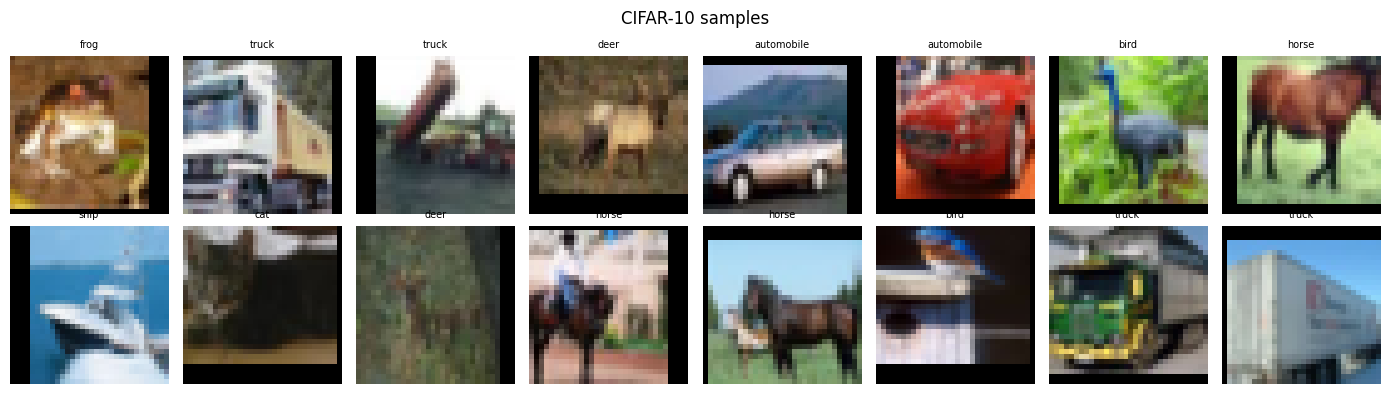

In [11]:
# Visualize some training samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
std = torch.tensor(CIFAR_STD).view(3, 1, 1)
for i, ax in enumerate(axes.flat):
    img, label = train_ds[i]
    img = (img * std + mean).clamp(0, 1).permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(CLASSES[label], fontsize=7)
    ax.axis("off")
plt.suptitle("CIFAR-10 samples")
plt.tight_layout()
plt.show()

In [12]:
def train_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if scaler is not None:  # mixed precision
            with torch.cuda.amp.autocast():
                logits = model(X)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += X.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_loss += criterion(logits, y).item() * X.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += X.size(0)
    return total_loss / total, correct / total

In [13]:
model = ResNet(n_classes=10).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(
    model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True
)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.1, steps_per_epoch=len(train_dl), epochs=30
)
scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(30):
    tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion, scaler)
    vl_loss, vl_acc = eval_epoch(model, val_dl, criterion)
    scheduler.step()
    for k, v in zip(
        ["train_loss", "val_loss", "train_acc", "val_acc"],
        [tr_loss, vl_loss, tr_acc, vl_acc],
    ):
        history[k].append(v)
    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:2d} | train {tr_loss:.4f}/{tr_acc:.4f} | val {vl_loss:.4f}/{vl_acc:.4f} | lr {scheduler.get_last_lr()[0]:.5f}"
        )

/tmp/ipykernel_5826/292938852.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None
/tmp/ipykernel_5826/854702333.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  5 | train 0.9379/0.8150 | val 1.0648/0.7640 | lr 0.00400
Epoch 10 | train 0.7781/0.8852 | val 0.8403/0.8574 | lr 0.00401
Epoch 15 | train 0.6981/0.9203 | val 0.8055/0.8700 | lr 0.00402
Epoch 20 | train 0.6473/0.9418 | val 0.8454/0.8590 | lr 0.00403
Epoch 25 | train 0.6130/0.9572 | val 0.7561/0.8949 | lr 0.00405
Epoch 30 | train 0.5899/0.9665 | val 0.7608/0.8947 | lr 0.00407


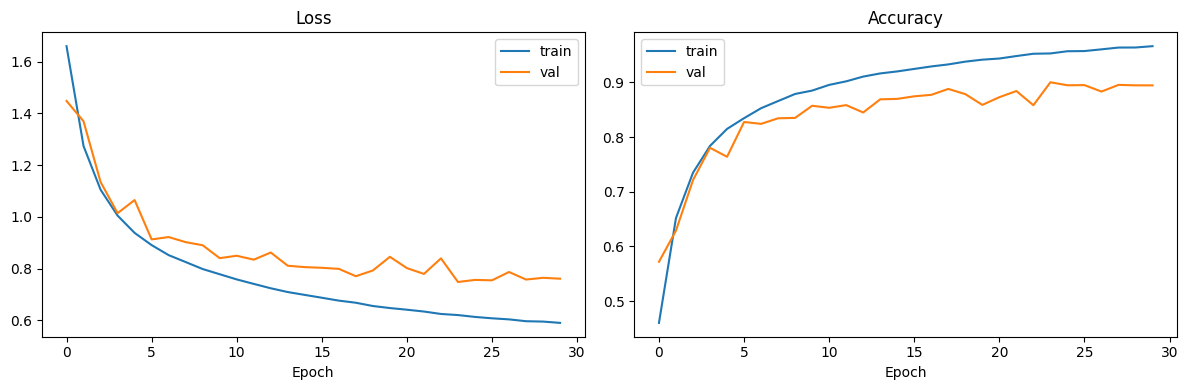

Best val accuracy: 0.9004


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()
print(f'Best val accuracy: {max(history["val_acc"]):.4f}')

---
## 9. Feature Map Visualization

See what the convolutional filters detect at each stage.

In [ ]:
# Get a single image
img, label = val_ds[0]
img_t = img.unsqueeze(0).to(device)  # (1, 3, 32, 32)

# Extract intermediate feature maps using hooks
feature_maps = {}


def make_hook(name):
    def hook(module, inp, out):
        feature_maps[name] = out.detach().cpu()

    return hook


model.stem[0].register_forward_hook(make_hook("stem"))
model.stage1[0].bn2.register_forward_hook(make_hook("stage1"))
model.stage2[0].bn2.register_forward_hook(make_hook("stage2"))
model.stage3[0].bn2.register_forward_hook(make_hook("stage3"))

model.eval()
with torch.no_grad():
    _ = model(img_t)

fig, axes = plt.subplots(4, 8, figsize=(14, 8))
stage_names = ["stem", "stage1", "stage2", "stage3"]
for row, name in enumerate(stage_names):
    fmap = feature_maps[name][0]  # (C, H, W)
    n_show = min(8, fmap.shape[0])
    for col in range(8):
        ax = axes[row, col]
        if col < n_show:
            ax.imshow(fmap[col], cmap="viridis")
            ax.set_title(f"ch {col}", fontsize=6)
        ax.axis("off")
    axes[row, 0].set_ylabel(name, fontsize=8)
plt.suptitle(f'Feature maps — "{CLASSES[label]}"')
plt.tight_layout()
plt.show()

---
## 10. Depthwise Separable Convolution Block

MobileNet-style: ~8–9× fewer operations than a standard $3\times 3$ conv.

In [ ]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        # Depthwise: one 3x3 filter per input channel
        self.dw = nn.Sequential(
            nn.Conv2d(
                in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False
            ),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
        )
        # Pointwise: 1x1 conv to mix channels
        self.pw = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.pw(self.dw(x))


def count_params(m):
    return sum(p.numel() for p in m.parameters())


standard = nn.Conv2d(64, 128, 3, padding=1)
ds_conv = DepthwiseSeparableConv(64, 128)

print(f"Standard conv params:  {count_params(standard):,}")
print(f"Depthwise-sep params:  {count_params(ds_conv):,}")
print(f"Reduction factor: {count_params(standard)/count_params(ds_conv):.1f}x")

---
## 11. GradCAM — Where the Model Looks

Gradient-weighted Class Activation Maps (GradCAM) visualize which spatial regions contributed most to a prediction.

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        # Global average pool gradients -> importance weights
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# Apply to the last convolutional layer
gradcam = GradCAM(model, model.stage4[-1].conv2)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
mean_t = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_STD).view(3, 1, 1)

for i in range(6):
    img, label = val_ds[i * 100]
    img_t = img.unsqueeze(0).to(device)
    img_t.requires_grad = True
    cam, pred_idx = gradcam(img_t)

    # Original image (denormalized)
    img_show = (img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[0, i].imshow(img_show)
    axes[0, i].set_title(f"True: {CLASSES[label]}", fontsize=7)
    axes[0, i].axis("off")

    # GradCAM overlay
    axes[1, i].imshow(img_show)
    axes[1, i].imshow(cam.numpy(), alpha=0.5, cmap="jet")
    axes[1, i].set_title(f"Pred: {CLASSES[pred_idx]}", fontsize=7)
    axes[1, i].axis("off")

plt.suptitle("GradCAM — row 1: image, row 2: activation heatmap")
plt.tight_layout()
plt.show()

---
## 12. Transfer Learning

Fine-tune a pretrained ResNet-18 on CIFAR-10. Much faster convergence than training from scratch.

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained on ImageNet
pretrained = resnet18(weights=ResNet18_Weights.DEFAULT)

# Strategy 1 — Feature extraction: freeze all layers, replace head only
for param in pretrained.parameters():
    param.requires_grad = False
pretrained.fc = nn.Linear(
    pretrained.fc.in_features, 10
)  # new head, unfrozen by default

trainable = sum(p.numel() for p in pretrained.parameters() if p.requires_grad)
total = sum(p.numel() for p in pretrained.parameters())
print(
    f"Feature extraction: {trainable:,} / {total:,} params trainable ({100*trainable/total:.1f}%)"
)

# Strategy 2 — Fine-tuning: unfreeze all, but use a lower LR for the backbone
for param in pretrained.parameters():
    param.requires_grad = True

backbone_params = [p for name, p in pretrained.named_parameters() if "fc" not in name]
head_params = list(pretrained.fc.parameters())

optimizer_ft = optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": 1e-4,
        },  # low LR: don't destroy pretrained features
        {"params": head_params, "lr": 1e-3},  # higher LR: head is newly initialized
    ],
    weight_decay=1e-4,
)

print("\nFine-tuning with differential LRs:")
print(f"  Backbone LR: 1e-4")
print(f"  Head LR:     1e-3")